### This code provides supports for results on Analyses for Aging-Specific Services, including those in Main Text section 2.5 and SI section A.9.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import statsmodels.api as sm

d:\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
f_old_svc=['Nursing and Residential Care Facilities','Services for the Elderly and Persons with Disabilities','Home Health Care Services','Personal Care Services']

usecol=['census_block_group','social_child_type','demand_ratios','demand_met_in_local']

df_list=[]

###data source 1: childtype accratio
for ctype in f_old_svc:
    df_list.append(pd.read_csv('data/A for aging specific services/sumAll_'+ctype+'.csv',usecols=usecol))
df_f_old=pd.concat(df_list)
###data source 1: childtype accratio

###data source 2: census data
df_census_all=pd.read_csv('data/census/all_census_data_with_location.csv')
###data source 2: census data

df_census_all['census_block_group']=df_census_all['census_block_group'].astype(str)

df_age=df_census_all[['census_block_group','percent_above_65']]
df_age['52age']=df_age.apply(lambda x: 0 if x['percent_above_65']<0.2 else 0.5, axis=1)
df_age['52age']=df_age.apply(lambda x: 1 if x['percent_above_65']>0.5 else x['52age'], axis=1)

df_f_old['census_block_group']=df_f_old['census_block_group'].astype(str)

df_f_old=pd.merge(df_f_old,df_age,on='census_block_group',how='left') 

dict_state={'1': 'AL', '2': 'AK', '4': 'AZ', '5': 'AR', '6': 'CA', '8': 'CO', '9': 'CT', '10': 'DE', '11': 'DC', '12': 'FL', '13': 'GA', '15': 'HI', '16': 'ID',
            '17': 'IL', '18': 'IN', '19': 'IA', '20': 'KS', '21': 'KY', '22': 'LA', '23': 'ME', '24': 'MD', '25': 'MA', '26': 'MI', '27': 'MN', '28': 'MS', '29': 'MO',
            '30': 'MT', '31': 'NE', '32': 'NV', '33': 'NH', '34': 'NJ', '35': 'NM', '36': 'NY', '37': 'NC', '38': 'ND', '39': 'OH', '40': 'OK', '41': 'OR', '42': 'PA', 
            '44': 'RI', '45': 'SC', '46': 'SD', '47': 'TN', '48': 'TX', '49': 'UT', '50': 'VT', '51': 'VA', '53': 'WA', '54': 'WV', '55': 'WI', '56': 'WY', '60': 'AS', 
            '66': 'GU', '69': 'MP', '72': 'PR', '74': 'UM', '78': 'VI'}
df_f_old['state']=df_f_old.apply(lambda x: dict_state[x['census_block_group'][0:2]] if len(x['census_block_group']) ==12 else  dict_state[x['census_block_group'][0:1]] , axis=1  )

C:\Users\Linao\AppData\Local\Temp\ipykernel_19588\2524446011.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_age['52age']=df_age.apply(lambda x: 0 if x['percent_above_65']<0.2 else 0.5, axis=1)
C:\Users\Linao\AppData\Local\Temp\ipykernel_19588\2524446011.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_age['52age']=df_age.apply(lambda x: 1 if x['percent_above_65']>0.5 else x['52age'], axis=1)


old_num_obs_forNursing and Residential Care Facilities: 1645
old_num_obs_forServices for the Elderly and Persons with Disabilities: 401
old_num_obs_forHome Health Care Services: 676
old_num_obs_forPersonal Care Services: 1356


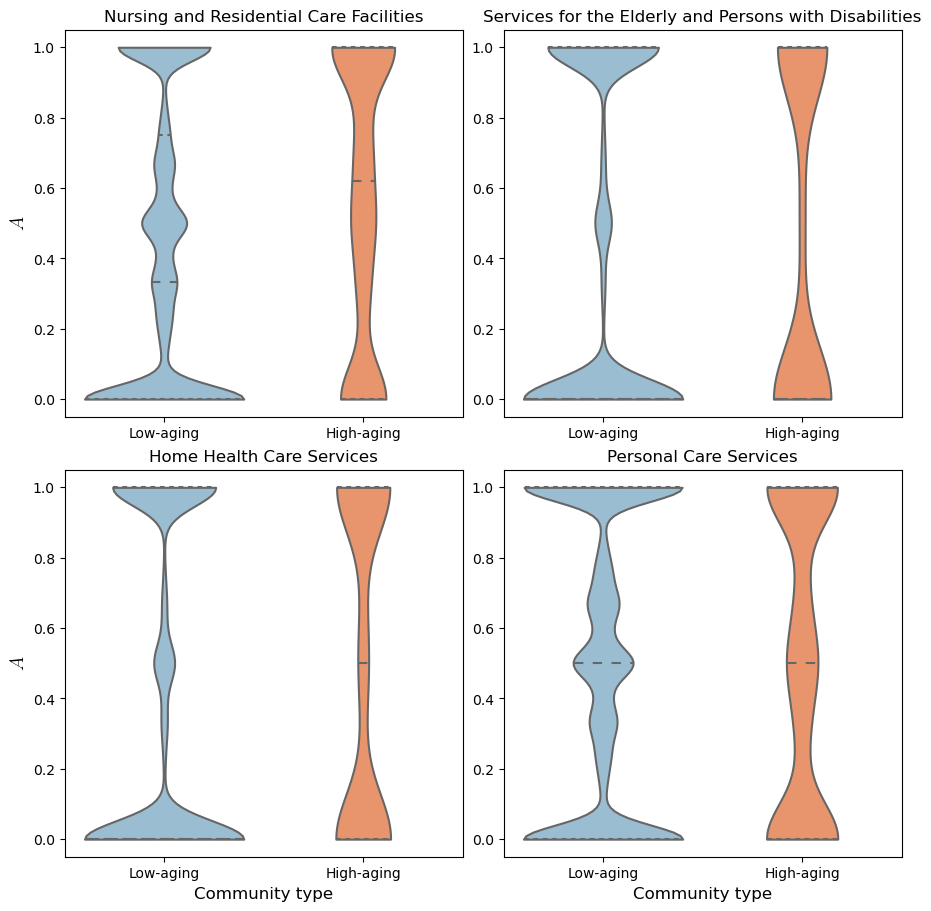

In [3]:
colors={0:'#91bfdb',1: '#fc8d59'}

fig, ax=plt.subplots(2,2,constrained_layout=True, figsize=(9, 9))
for i,ctype in enumerate(f_old_svc):
    if i>1:
        k=1
        g=i%2
    else:
        k=0
        g=i

    kk=len( df_f_old[(df_f_old['social_child_type']==ctype)&(df_f_old['52age']==1)].dropna() )
    print('old_num_obs_for'+ctype+':', kk )
    sn=sns.violinplot(x='52age',y='demand_met_in_local',ax=ax[k,g],
                        data=df_f_old[(df_f_old['social_child_type']==ctype)&(df_f_old['52age']!=0.5)].dropna(),cut=0.0,inner="quartiles",palette=colors)
    sn.set_title(ctype)
    if k>0:
        sn.set_xlabel('Community type', fontsize=12)
    else:
        sn.set_xlabel('')
    if g<1:
        sn.set_ylabel(r'$A$', fontsize=14, usetex=True)
    else:
        sn.set_ylabel('')
    ax[k,g].set_xticks([0, 1])  
    ax[k,g].set_xticklabels(['Low-aging', 'High-aging'])

In [7]:
df_abcd=df_f_old[(df_f_old['52age']!=0.5)].dropna()
df_abcd['community_type']=df_abcd.apply(lambda x: 'High-aging' if x['52age']==1 else 'Low-aging' ,axis=1)
df_abcd=df_abcd.rename(columns={'social_child_type':'service_type','demand_met_in_local':'A'})
df_abcd=df_abcd[['census_block_group','service_type','A','community_type','state']]

In [8]:
df_abcd

,census_block_group,service_type,A,community_type,state
4,10010203001,Nursing and Residential Care Facilities,0.000000,Low-aging,AL
7,10010204002,Nursing and Residential Care Facilities,1.000000,Low-aging,AL
10,10010205001,Nursing and Residential Care Facilities,0.307692,Low-aging,AL
11,10010205002,Nursing and Residential Care Facilities,0.285714,Low-aging,AL
13,10010206001,Nursing and Residential Care Facilities,1.000000,Low-aging,AL
...,...,...,...,...,...
881215,721435506021,Personal Care Services,0.000000,Low-aging,PR
881220,721455601003,Personal Care Services,0.000000,Low-aging,PR
881274,721497205022,Personal Care Services,0.000000,Low-aging,PR
881293,721519510001,Personal Care Services,0.000000,Low-aging,PR


In [4]:
#fig.savefig(r'..\..\..\R1\new results\analyses for elderly\distribution_A_compare.png',dpi=600,bbox_inches='tight')

In [4]:
from scipy.stats import mannwhitneyu, shapiro
from statsmodels.stats.multitest import multipletests

dic_pv = {}
raw_p_list = []
ctype_list = []

# 正态性检验结果
print("Normality check:")
for ctype in f_old_svc:
    group1 = df_f_old[(df_f_old['social_child_type'] == ctype) & (df_f_old['52age'] == 1)].dropna()['demand_met_in_local']
    group2 = df_f_old[(df_f_old['social_child_type'] == ctype) & (df_f_old['52age'] == 0)].dropna()['demand_met_in_local']

    # 正态性检验
    stat1, p1 = shapiro(group1)
    stat2, p2 = shapiro(group2)
    print(f"{ctype}: group1 p={p1:.3e}, group2 p={p2:.3e}")

    # 非参数检验
    u_stat, p_val = mannwhitneyu(group1, group2, alternative='two-sided')
    raw_p_list.append(p_val)
    ctype_list.append(ctype)
    print(u_stat)

# 多重比较校正
_, corrected_p_list, _, _ = multipletests(raw_p_list, method='fdr_bh')

# 显著性符号函数
def sig_symbol(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

# 保存结果
for i, ctype in enumerate(ctype_list):
    p_corr = corrected_p_list[i]
    dic_pv[ctype] = 'p<0.001' if p_corr < 0.001 else f"p={round(p_corr, 3)}"
    print(f"{ctype}: corrected p = {dic_pv[ctype]}, significance = {sig_symbol(p_corr)}")

Normality check:
Nursing and Residential Care Facilities: group1 p=2.636e-40, group2 p=0.000e+00
121610955.0


d:\anaconda3\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


Services for the Elderly and Persons with Disabilities: group1 p=4.265e-27, group2 p=0.000e+00
9094563.5
Home Health Care Services: group1 p=1.015e-32, group2 p=0.000e+00
19846781.5
Personal Care Services: group1 p=6.316e-39, group2 p=0.000e+00
81877004.5
Nursing and Residential Care Facilities: corrected p = p<0.001, significance = ***
Services for the Elderly and Persons with Disabilities: corrected p = p=0.09, significance = n.s.
Home Health Care Services: corrected p = p<0.001, significance = ***
Personal Care Services: corrected p = p=0.887, significance = n.s.


In [5]:
dic_pv

{'Nursing and Residential Care Facilities': 'p<0.001',
 'Services for the Elderly and Persons with Disabilities': 'p=0.09',
 'Home Health Care Services': 'p<0.001',
 'Personal Care Services': 'p=0.887'}

In [18]:

for i,ctype in enumerate(f_old_svc):
    print ( ctype , len ( df_f_old[(df_f_old['social_child_type']==ctype)&(df_f_old['52age']==1)&(df_f_old['demand_met_in_local']==0)] ), 
           len ( df_f_old[(df_f_old['social_child_type']==ctype)&(df_f_old['52age']==1)].dropna(subset=['demand_met_in_local'], axis=0) ) )



Nursing and Residential Care Facilities 448 1645
Services for the Elderly and Persons with Disabilities 202 401
Home Health Care Services 301 676
Personal Care Services 489 1356


In [6]:
sum_state=[]
for ctype in f_old_svc:
    for state in df_f_old[(df_f_old['social_child_type']==ctype)&(df_f_old['52age']==1)].dropna()['state'].unique():
        sum_state.append( (ctype, state, 
                           len(df_f_old[(df_f_old['social_child_type']==ctype)&(df_f_old['52age']==1)&(df_f_old['state']==state)].dropna() ),
                            len(df_f_old[(df_f_old['social_child_type']==ctype)&(df_f_old['52age']==1)&(df_f_old['state']==state)&(df_f_old['demand_met_in_local']==0)] ) ,
                            len(df_f_old[(df_f_old['social_child_type']==ctype)&(df_f_old['52age']==1)&(df_f_old['state']==state)&(df_f_old['demand_met_in_local']==0)] ) / len(df_f_old[(df_f_old['social_child_type']==ctype)&(df_f_old['52age']==1)&(df_f_old['state']==state)].dropna() )
                             ) )

df_sum_state=pd.DataFrame(sum_state,columns=['ctype','state','num_old','num_old_zero_A','ratio_old_zero_A'])


In [10]:
df_e=df_sum_state[df_sum_state['state'].isin(['AZ','CA','FL','NJ','NY','TX'])][['ctype','state','ratio_old_zero_A']].rename(columns={'ctype':'service_type','ratio_old_zero_A':'ratio_of_HighAging_CBG_with_zero_A'})

In [11]:
df_e

,service_type,state,ratio_of_HighAging_CBG_with_zero_A
1,Nursing and Residential Care Facilities,AZ,0.413265
3,Nursing and Residential Care Facilities,CA,0.272152
7,Nursing and Residential Care Facilities,FL,0.248476
10,Nursing and Residential Care Facilities,NJ,0.288136
11,Nursing and Residential Care Facilities,NY,0.244898
13,Nursing and Residential Care Facilities,TX,0.360000
47,Services for the Elderly and Persons with Disa...,AZ,0.704545
49,Services for the Elderly and Persons with Disa...,CA,0.450000
53,Services for the Elderly and Persons with Disa...,FL,0.475000
56,Services for the Elderly and Persons with Disa...,NJ,0.600000


In [19]:
dic_pv

{'Nursing and Residential Care Facilities': 'p<0.001',
 'Services for the Elderly and Persons with Disabilities': 'p=0.09',
 'Home Health Care Services': 'p<0.001',
 'Personal Care Services': 'p=0.887'}

old_num_obs_forNursing and Residential Care Facilities: 1645
old_num_obs_forServices for the Elderly and Persons with Disabilities: 401
old_num_obs_forHome Health Care Services: 676
old_num_obs_forPersonal Care Services: 1356


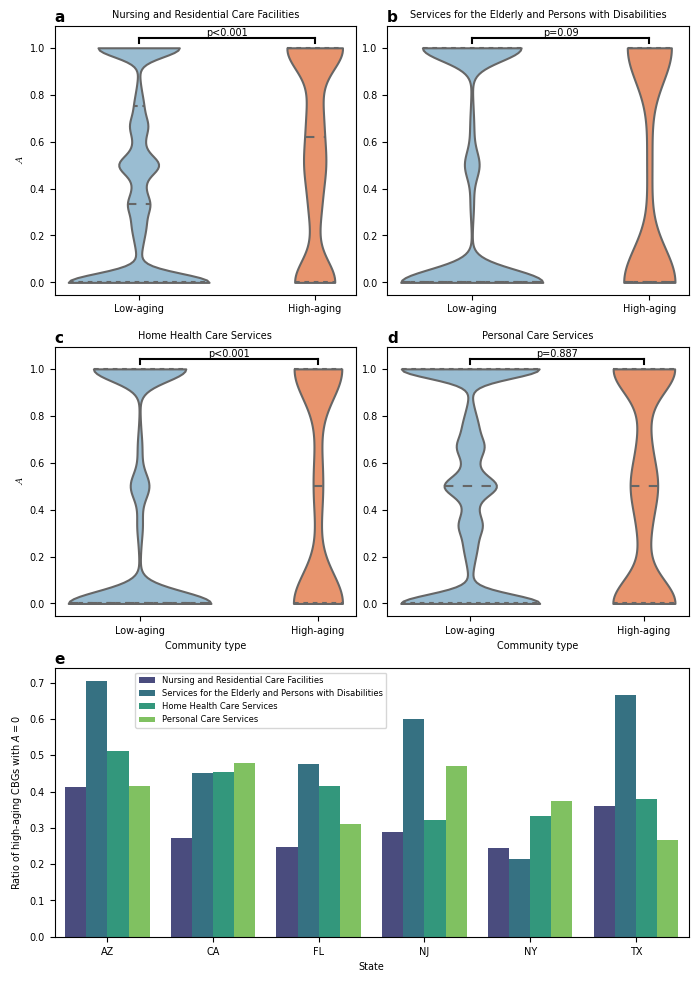

In [7]:
width_in_inches = 180 * 0.0393701
height_in_inches =width_in_inches/10*14
figg=plt.figure(figsize=(width_in_inches,height_in_inches))

fig=gridspec.GridSpec(3,2)

#ax0=plt.subplot(fig[0,:3])

ax1=plt.subplot(fig[2,:2])

colors={0:'#91bfdb',1: '#fc8d59'}

ax1_list=[]
for i,ctype in enumerate(f_old_svc):
    if i>1:
        k=1
        g=i%2
    else:
        k=0
        g=i
    ax1_list.append(plt.subplot(fig[k,g]))
    kk=len( df_f_old[(df_f_old['social_child_type']==ctype)&(df_f_old['52age']==1)].dropna() )
    print('old_num_obs_for'+ctype+':', kk )
    sn=sns.violinplot(x='52age',y='demand_met_in_local',ax=plt.subplot(fig[k,g]),
                        data=df_f_old[(df_f_old['social_child_type']==ctype)&(df_f_old['52age']!=0.5)].dropna(),cut=0.0,inner="quartiles",palette=colors)
    sn.set_title(ctype,fontsize=7)
    if k>0:
        sn.set_xlabel('Community type', fontsize=7)
    else:
        sn.set_xlabel('')
    if g<1:
        sn.set_ylabel(r'$A$', fontsize=7, usetex=True)
    else:
        sn.set_ylabel('')
    sn.set_xticks([0, 1])  
    sn.set_xticklabels(['Low-aging', 'High-aging'])
    sn.tick_params(axis='both', which='both', bottom=True, left=True,labelsize=7)  

    loc_dict={}
    for j, violin in enumerate(sn.collections):
        #if j%2==0:
        vertices = violin.get_paths()[0].vertices
        top_position_y = vertices[:, 1].max()
        
        lowlist=[]
        for v in vertices:
            if v[1]==0:
                lowlist.append(v[0])
        top_position_x = (max(lowlist)+min(lowlist) )/2
        loc_dict[j]=(top_position_x,top_position_y)

        #print(j)
    t=0.02
    x1=loc_dict[0][0]
    y1=loc_dict[0][1]+t
    x2=loc_dict[1][0]
  

    sn.plot([x1,x1],[y1,y1+t],color='black')
    sn.plot([x2,x2],[y1,y1+t],color='black')
    sn.plot([x2,x1],[y1+t,y1+t],color='black')

    sn.text((x1+x2)/2,y1+1.6*t,dic_pv[ctype],ha='center',fontsize=7)


feasible_state=['AZ','CA','FL','NJ','NY','TX']
sn2=sns.barplot(x='state', y='ratio_old_zero_A',hue='ctype', data=df_sum_state[(df_sum_state['state'].isin(feasible_state))], palette="viridis",ax=ax1)
sn2.set_ylabel(r'Ratio of high-aging CBGs with $A=0$', fontsize=7)
sn2.set_xlabel('State', fontsize=7)
sn2.tick_params(axis='both', which='both', bottom=True, left=True,labelsize=7)  

handles, labels = ax1.get_legend_handles_labels()
legend = ax1.legend(
    handles, labels,
    title='',          # 
    loc='upper right', # 
    bbox_to_anchor=(0.53, 1),  # 
    fontsize=6,        #
    frameon=True      #
)

labels = ['a', 'b', 'c', 'd', 'e']
axes_list = ax1_list+ [ax1]  # 合并所有子图的 axes 对象
for i, ax_i in enumerate(axes_list):
    if i<4:
        ax_i.text(-0.0, 1.06, labels[i], transform=ax_i.transAxes, fontsize=11, fontweight='bold', va='top', ha='left')
    else:
        ax_i.text(-0.0, 1.06, labels[i], transform=ax_i.transAxes, fontsize=11, fontweight='bold', va='top', ha='left')

plt.subplots_adjust(hspace=8) 
figg.tight_layout()

In [ ]:
#figg.savefig(r'D:\main\1_research\P10_Mobility\p10_aging mobility\figures_colorblind_safe\fig6.pdf', dpi=300, bbox_inches='tight', format='pdf')


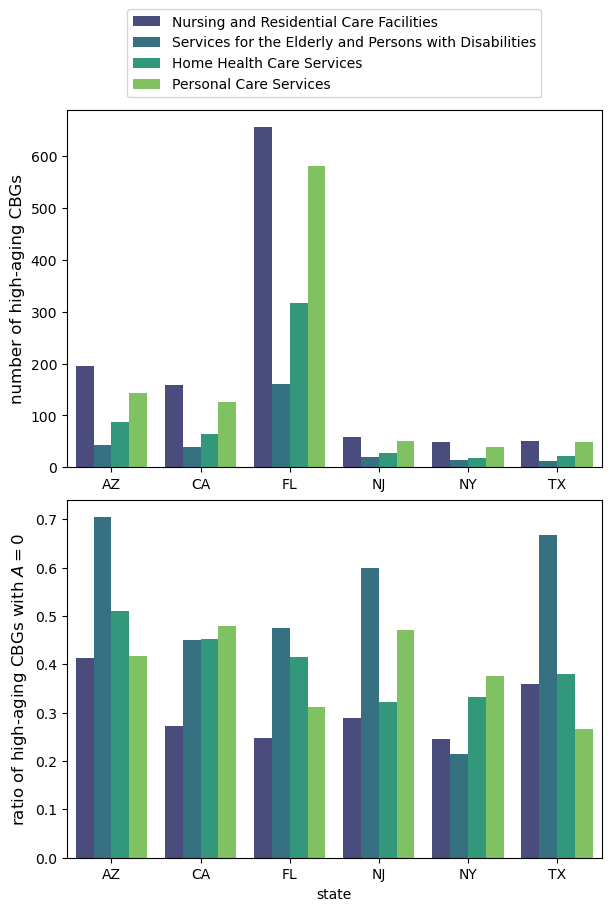

In [12]:
feasible_state=['AZ','CA','FL','NJ','NY','TX']
fig, ax=plt.subplots(2,1,constrained_layout=True, figsize=(6, 9))
sn1=sns.barplot(x='state', y='num_old',hue='ctype', data=df_sum_state[(df_sum_state['state'].isin(feasible_state))], palette="viridis",ax=ax[0])
sn1.set_xlabel('')
sn1.set_ylabel('number of high-aging CBGs', fontsize=12)
ax[0].legend(title='', loc='upper center', bbox_to_anchor=(0.5, 1.3),  ncol=1)

sn2=sns.barplot(x='state', y='ratio_old_zero_A',hue='ctype', data=df_sum_state[(df_sum_state['state'].isin(feasible_state))], palette="viridis",ax=ax[1])
sn2.set_ylabel(r'ratio of high-aging CBGs with $A=0$', fontsize=12)
ax[1].legend().set_visible(False) 

In [13]:
#fig.savefig(r'..\..\..\R1\new results\analyses for elderly\H_CBG_0_A.png',dpi=600,bbox_inches='tight')

In [13]:
df_abcd

,census_block_group,service_type,A,community_type,state
4,10010203001,Nursing and Residential Care Facilities,0.000000,Low-aging,AL
7,10010204002,Nursing and Residential Care Facilities,1.000000,Low-aging,AL
10,10010205001,Nursing and Residential Care Facilities,0.307692,Low-aging,AL
11,10010205002,Nursing and Residential Care Facilities,0.285714,Low-aging,AL
13,10010206001,Nursing and Residential Care Facilities,1.000000,Low-aging,AL
...,...,...,...,...,...
881215,721435506021,Personal Care Services,0.000000,Low-aging,PR
881220,721455601003,Personal Care Services,0.000000,Low-aging,PR
881274,721497205022,Personal Care Services,0.000000,Low-aging,PR
881293,721519510001,Personal Care Services,0.000000,Low-aging,PR


In [12]:
df_e

,service_type,state,ratio_of_HighAging_CBG_with_zero_A
1,Nursing and Residential Care Facilities,AZ,0.413265
3,Nursing and Residential Care Facilities,CA,0.272152
7,Nursing and Residential Care Facilities,FL,0.248476
10,Nursing and Residential Care Facilities,NJ,0.288136
11,Nursing and Residential Care Facilities,NY,0.244898
13,Nursing and Residential Care Facilities,TX,0.360000
47,Services for the Elderly and Persons with Disa...,AZ,0.704545
49,Services for the Elderly and Persons with Disa...,CA,0.450000
53,Services for the Elderly and Persons with Disa...,FL,0.475000
56,Services for the Elderly and Persons with Disa...,NJ,0.600000


In [14]:
#with pd.ExcelWriter('SourceData_Fig6.xlsx') as writer:
#    df_abcd.to_excel(writer, sheet_name='Fig6a-d', index=False)
#    df_e.to_excel(writer, sheet_name='Fig6e', index=False)